<a href="https://colab.research.google.com/github/avikumart/DA-DS-Questions/blob/main/R_codes/Classification_modeling_in_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
load("/content/Titanic.RData")

### Titanic classification

In [2]:
set.seed(1234)
id <- sample(1:nrow(data), 100, replace=TRUE)
train <- data[-id,]
test <- data[id,]

In [6]:
head(train)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
,<int>,<fct>,<fct>,<dbl>,<int>,<int>,<dbl>,<fct>
1,0,3,male,22,1,0,7.2500,S
2,1,1,female,38,1,0,71.2833,C
3,1,3,female,26,0,0,7.9250,S
5,0,3,male,35,0,0,8.0500,S
7,0,1,male,54,0,0,51.8625,S
8,0,3,male,2,3,1,21.0750,S


In [7]:
summary(train)

    Survived      Pclass      Sex           Age            SibSp       
 Min.   :0.0000   1:159   female:227   Min.   : 0.42   Min.   :0.0000  
 1st Qu.:0.0000   2:147   male  :391   1st Qu.:21.00   1st Qu.:0.0000  
 Median :0.0000   3:312                Median :28.00   Median :0.0000  
 Mean   :0.4013                        Mean   :29.86   Mean   :0.5227  
 3rd Qu.:1.0000                        3rd Qu.:38.00   3rd Qu.:1.0000  
 Max.   :1.0000                        Max.   :80.00   Max.   :5.0000  
     Parch             Fare        Embarked
 Min.   :0.0000   Min.   :  0.00   C:113   
 1st Qu.:0.0000   1st Qu.:  8.05   Q: 25   
 Median :0.0000   Median : 15.85   S:480   
 Mean   :0.4401   Mean   : 34.47           
 3rd Qu.:1.0000   3rd Qu.: 33.00           
 Max.   :6.0000   Max.   :512.33           

In [9]:
# use glm function to develop the logistic regression model in R
glm.fit <- glm(Survived ~ ., family=binomial, data=train)
summary(glm.fit)


Call:
glm(formula = Survived ~ ., family = binomial, data = train)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)  4.5647888  0.5808354   7.859 3.87e-15 ***
Pclass2     -1.5236975  0.3628205  -4.200 2.67e-05 ***
Pclass3     -2.7208284  0.3787541  -7.184 6.79e-13 ***
Sexmale     -2.6184314  0.2405275 -10.886  < 2e-16 ***
Age         -0.0454943  0.0091858  -4.953 7.32e-07 ***
SibSp       -0.3934087  0.1404196  -2.802  0.00508 ** 
Parch       -0.0079439  0.1299285  -0.061  0.95125    
Fare         0.0008388  0.0026543   0.316  0.75198    
EmbarkedQ   -0.6913307  0.6340640  -1.090  0.27557    
EmbarkedS   -0.1962754  0.2949124  -0.666  0.50571    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 832.49  on 617  degrees of freedom
Residual deviance: 543.45  on 608  degrees of freedom
AIC: 563.45

Number of Fisher Scoring iterations: 5


In [10]:
round(exp(cbind(OR=coef(glm.fit), confint(glm.fit))[-1,]),4)

Waiting for profiling to be done...



,OR,2.5 %,97.5 %
Pclass2,0.2179,0.1059,0.4405
Pclass3,0.0658,0.0309,0.1371
Sexmale,0.0729,0.0449,0.1155
Age,0.9555,0.9380,0.9725
SibSp,0.6748,0.5073,0.8813
Parch,0.9921,0.7629,1.2757
Fare,1.0008,0.9958,1.0067
EmbarkedQ,0.5009,0.1399,1.7065
EmbarkedS,0.8218,0.4617,1.4705


In [12]:
# predict on the test data
test.proba <- predict(glm.fit, newdata = test[,-1], type="response")
head(test.proba)

354        130        783        809        504        125 
0.07680418 0.04688041 0.61204378 0.17697331 0.49310967 0.34305158

In [13]:
test.pred <- rep(1, length(test.proba))
test.pred[test.proba<0.5] <- 0

In [14]:
table(test.pred, test$Survived)

         
test.pred  0  1
        0 47 11
        1 11 31

In [15]:
mean(test.pred==test$Survived)

[1] 0.78

In [18]:
library(ROCR)

In [17]:
install.packages("ROCR")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bitops’, ‘gtools’, ‘caTools’, ‘gplots’




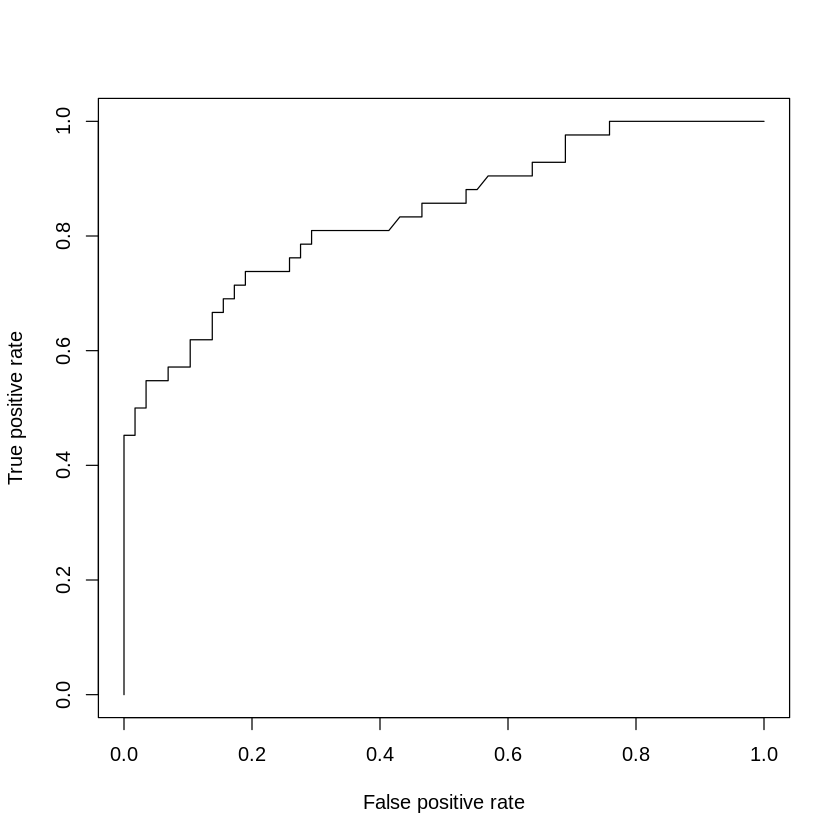

In [20]:
# Creat an ROC curve using above lib
test.pred <- predict(glm.fit, newdata=test[,-1], type="response")
pr <- prediction(test.proba, test$Survived)
prf <- performance(pr, measure = "tpr", x.measure = "fpr")
plot(prf)

In [23]:
# get an auc score
auc <- performance(pr, measure = "auc")
auc <- auc@y.values[[1]]
auc

[1] 0.8390805

### SA heart data

In [24]:
load("/content/SAheart.RData")
hd.fit <- glm(chd~., data=SAheart, family=binomial)
summary(hd.fit)


Call:
glm(formula = chd ~ ., family = binomial, data = SAheart)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -6.1507209  1.3082600  -4.701 2.58e-06 ***
sbp             0.0065040  0.0057304   1.135 0.256374    
tobacco         0.0793764  0.0266028   2.984 0.002847 ** 
ldl             0.1739239  0.0596617   2.915 0.003555 ** 
adiposity       0.0185866  0.0292894   0.635 0.525700    
famhistPresent  0.9253704  0.2278940   4.061 4.90e-05 ***
typea           0.0395950  0.0123202   3.214 0.001310 ** 
obesity        -0.0629099  0.0442477  -1.422 0.155095    
alcohol         0.0001217  0.0044832   0.027 0.978350    
age             0.0452253  0.0121298   3.728 0.000193 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 596.11  on 461  degrees of freedom
Residual deviance: 472.14  on 452  degrees of freedom
AIC: 492.14

Number of Fisher Scoring iterations

In [25]:
round(exp(cbind(OR=coef(hd.fit),
confint(hd.fit))[-1,]), 4)

Waiting for profiling to be done...



,OR,2.5 %,97.5 %
sbp,1.0065,0.9953,1.0180
tobacco,1.0826,1.0289,1.1424
ldl,1.1900,1.0610,1.3417
adiposity,1.0188,0.9623,1.0797
famhistPresent,2.5228,1.6178,3.9581
typea,1.0404,1.0160,1.0664
obesity,0.9390,0.8588,1.0221
alcohol,1.0001,0.9912,1.0089
age,1.0463,1.0220,1.0719


## LDA classification

In [26]:
install.packages("MASS")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [28]:
library(MASS)
lda.fit <- lda(Survived ~.,data=train)
lda.fit

Call:
lda(Survived ~ ., data = train)

Prior probabilities of groups:
        0         1 
0.5987055 0.4012945 

Group means:
    Pclass2   Pclass3   Sexmale      Age     SibSp     Parch     Fare
0 0.2108108 0.6486486 0.8405405 30.66622 0.5378378 0.3756757 23.11258
1 0.2782258 0.2903226 0.3225806 28.65323 0.5000000 0.5362903 51.40780
   EmbarkedQ EmbarkedS
0 0.04864865 0.8270270
1 0.02822581 0.7016129

Coefficients of linear discriminants:
                    LD1
Pclass2   -0.9326136940
Pclass3   -1.7233919994
Sexmale   -1.9577768325
Age       -0.0269587970
SibSp     -0.2251562076
Parch     -0.0176943391
Fare       0.0007282625
EmbarkedQ -0.3205428557
EmbarkedS -0.1621191166

In [30]:
# prior probas
lda.fit$prior

0         1 
0.5987055 0.4012945

In [31]:
coef(lda.fit)

,LD1
Pclass2,-0.9326136940
Pclass3,-1.7233919994
Sexmale,-1.9577768325
Age,-0.0269587970
SibSp,-0.2251562076
Parch,-0.0176943391
Fare,0.0007282625
EmbarkedQ,-0.3205428557
EmbarkedS,-0.1621191166


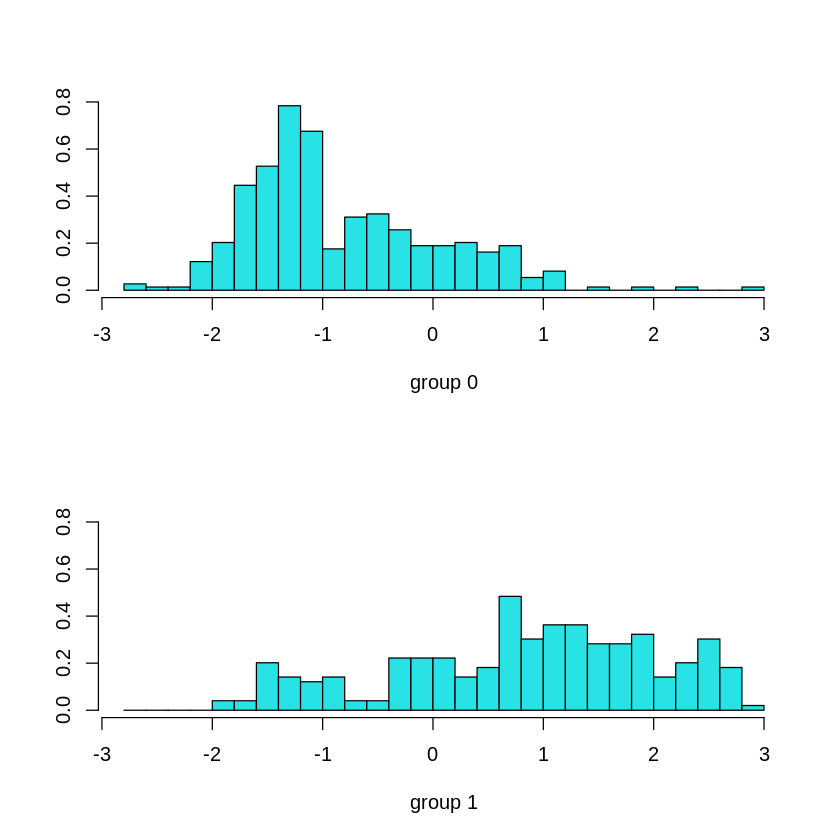

In [32]:
plot(lda.fit)

In [33]:
# prediction using lda
lda.pred <- predict(lda.fit, test[,-1])
names(lda.pred)

[1] "class"     "posterior" "x"

In [34]:
mean(lda.pred$class == test[,1])

[1] 0.78

### Iris data multiclass classification

In [35]:
data(iris)
head(iris)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


In [36]:
iris.fit <- lda(formula = Species ~ ., data = iris, CV=TRUE)
table(iris.fit$class, iris$Species)

            
             setosa versicolor virginica
  setosa         50          0         0
  versicolor      0         48         1
  virginica       0          2        49

In [37]:
# predict on test set
set.seed(1234)
train=sample(1:nrow(iris), 75)
iris.fit <- lda(Species ~ ., iris, subset=train)
test.pred <- predict(iris.fit, newdata=iris[-train,])
table(test.pred$class, iris[-train, "Species"])

            
             setosa versicolor virginica
  setosa         26          0         0
  versicolor      0         25         1
  virginica       0          1        22

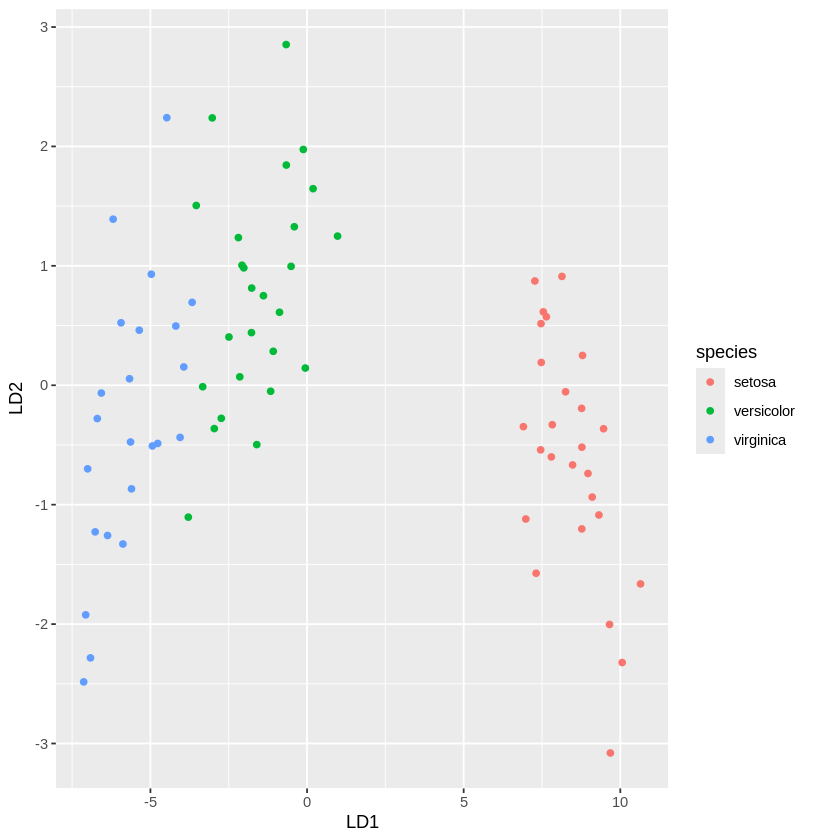

In [39]:
library(ggplot2)
test.lda <- data.frame(test.pred$x, species=iris[-train, "Species"])
ggplot(test.lda, aes(x=LD1, y=LD2, col=species)) +
geom_point()